# Notebook 01 — Explore the HC3 Dataset

**Project:** MSc AI Dissertation — AI-Generated Text Detection  
**Student:** Abdul Hannaan Mohammed | B00409227 | UWS  
**Week:** 1 of 13  

**Goal of this notebook:**
- Load the HC3 dataset from HuggingFace Hub
- Understand its structure and domains
- Compute and display key statistics
- Visualise sample distributions
- Save a summary CSV to `data/raw/`

**HC3 Reference:** Guo, B. et al. (2023) *How Close is ChatGPT to Human Experts?* arXiv:2301.07597

## 1. Install / Import Libraries

In [1]:
# Standard library imports
import os
import json
import warnings
warnings.filterwarnings('ignore')

# Data handling
import pandas as pd
import numpy as np

# HuggingFace Datasets — loads HC3 directly from the Hub
from datasets import load_dataset

# NLP utilities for token/word counting
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize

# Visualisation
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150   # high-res figures for dissertation
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Define Paths

All paths are relative to the project root so they work on any machine.

In [2]:
# Build absolute paths from this notebook's location
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))   # notebooks/
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)                  # MSc-AI-Detection/

DATA_RAW      = os.path.join(PROJECT_ROOT, 'data', 'raw')
DATA_PROCESSED = os.path.join(PROJECT_ROOT, 'data', 'processed')
RESULTS_FIGS  = os.path.join(PROJECT_ROOT, 'results', 'figures')
RESULTS_TABLES = os.path.join(PROJECT_ROOT, 'results', 'tables')

# Create directories if they don't exist yet
for path in [DATA_RAW, DATA_PROCESSED, RESULTS_FIGS, RESULTS_TABLES]:
    os.makedirs(path, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data raw dir: {DATA_RAW}')
print(f'Results figures dir: {RESULTS_FIGS}')

Project root: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection
Data raw dir: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\data\raw
Results figures dir: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures


## 3. Load HC3 Dataset from HuggingFace Hub

HC3 has multiple domain subsets. We load the `all` split which combines all domains.  
**First run downloads ~50MB — subsequent runs use the local cache.**

> **SCREENSHOT REMINDER:** After running this cell, take a screenshot of the output.  
> Save it as: `screenshots/01_hc3_dataset_loaded.png`

In [3]:
# Load the full HC3 dataset (all domains combined)
# This downloads from HuggingFace Hub on first run
print('Loading HC3 dataset from HuggingFace Hub...')
hc3 = load_dataset('Hello-SimpleAI/HC3', name='all')

print('\n--- Dataset Object ---')
print(hc3)

print('\n--- Available Splits ---')
for split_name in hc3:
    print(f'  {split_name}: {len(hc3[split_name])} rows')

Loading HC3 dataset from HuggingFace Hub...


Generating train split:   0%|          | 0/24322 [00:00<?, ? examples/s]


--- Dataset Object ---
DatasetDict({
    train: Dataset({
        features: ['id', 'question', 'human_answers', 'chatgpt_answers', 'source'],
        num_rows: 24322
    })
})

--- Available Splits ---
  train: 24322 rows


## 4. Inspect the Dataset Structure

HC3 is structured as question-answer pairs. Each row contains:
- `question` — the original question
- `human_answers` — list of human-written answers
- `chatgpt_answers` — list of ChatGPT-generated answers
- `source` — domain (medicine, finance, open_qa, etc.)

In [4]:
# Inspect the column schema
print('--- Column Features ---')
print(hc3['train'].features)

print('\n--- First Example Row ---')
example = hc3['train'][0]
print(f"Question: {example['question'][:200]}...")
print(f"\nHuman answers count: {len(example['human_answers'])}")
print(f"First human answer (first 300 chars): {example['human_answers'][0][:300]}...")
print(f"\nChatGPT answers count: {len(example['chatgpt_answers'])}")
print(f"First ChatGPT answer (first 300 chars): {example['chatgpt_answers'][0][:300]}...")
print(f"\nSource domain: {example['source']}")

--- Column Features ---
{'id': Value(dtype='string', id=None), 'question': Value(dtype='string', id=None), 'human_answers': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'chatgpt_answers': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'source': Value(dtype='string', id=None)}

--- First Example Row ---
Question: Why is every book I hear about a " NY Times # 1 Best Seller " ? ELI5 : Why is every book I hear about a " NY Times # 1 Best Seller " ? Should n't there only be one " # 1 " best seller ? Please explain...

Human answers count: 3
First human answer (first 300 chars): Basically there are many categories of " Best Seller " . Replace " Best Seller " by something like " Oscars " and every " best seller " book is basically an " oscar - winning " book . May not have won the " Best film " , but even if you won the best director or best script , you 're still an " oscar...

ChatGPT answers count: 1
First ChatGPT answer (first 300 chars): Th

## 5. Flatten HC3 into a Labelled DataFrame

We convert HC3's nested structure into a flat DataFrame where each row is a **single text sample** with:
- `text` — the answer text
- `label` — 0 for human, 1 for AI-generated
- `source` — domain
- `question` — the original question (for reference)

In [5]:
def flatten_hc3_split(hc3_split):
    """
    Converts an HC3 split (with nested human/chatgpt answer lists)
    into a flat DataFrame with one text sample per row.
    
    Labels: 0 = human-written, 1 = AI-generated
    """
    rows = []
    
    for item in hc3_split:
        question = item['question']
        source   = item['source']
        
        # Add each human answer as label 0
        for answer in item['human_answers']:
            if answer and answer.strip():  # skip empty strings
                rows.append({
                    'question': question,
                    'text':     answer.strip(),
                    'label':    0,              # 0 = human
                    'label_name': 'human',
                    'source':   source
                })
        
        # Add each ChatGPT answer as label 1
        for answer in item['chatgpt_answers']:
            if answer and answer.strip():  # skip empty strings
                rows.append({
                    'question': question,
                    'text':     answer.strip(),
                    'label':    1,              # 1 = AI-generated
                    'label_name': 'ai',
                    'source':   source
                })
    
    return pd.DataFrame(rows)


# Flatten the train split (HC3 only has one split called 'train')
print('Flattening HC3 into labelled DataFrame...')
df = flatten_hc3_split(hc3['train'])

print(f'Total samples: {len(df):,}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Flattening HC3 into labelled DataFrame...
Total samples: 85,431
Columns: ['question', 'text', 'label', 'label_name', 'source']


,question,text,label,label_name,source
0,"Why is every book I hear about a "" NY Times # ...","Basically there are many categories of "" Best ...",0,human,reddit_eli5
1,"Why is every book I hear about a "" NY Times # ...","If you 're hearing about it , it 's because it...",0,human,reddit_eli5
2,"Why is every book I hear about a "" NY Times # ...","One reason is lots of catagories . However , h...",0,human,reddit_eli5


## 6. Dataset Statistics

> **DISSERTATION NOTE:** The output of this section provides data for:  
> - Chapter 3 (Methodology) — Dataset Statistics Table  
> - Chapter 4 (Implementation) — Dataset description paragraph

In [6]:
# ── Basic counts ──────────────────────────────────────────────────────────────
total       = len(df)
n_human     = (df['label'] == 0).sum()
n_ai        = (df['label'] == 1).sum()
n_domains   = df['source'].nunique()
domains     = sorted(df['source'].unique().tolist())

print('=' * 55)
print('            HC3 DATASET STATISTICS')
print('=' * 55)
print(f'  Total samples        : {total:,}')
print(f'  Human-written (0)    : {n_human:,}  ({n_human/total*100:.1f}%)')
print(f'  AI-generated  (1)    : {n_ai:,}   ({n_ai/total*100:.1f}%)')
print(f'  Number of domains    : {n_domains}')
print(f'  Domains              : {domains}')
print('=' * 55)

# ── Per-domain breakdown ──────────────────────────────────────────────────────
domain_stats = df.groupby(['source', 'label_name']).size().unstack(fill_value=0)
domain_stats.columns.name = None
domain_stats['total'] = domain_stats.sum(axis=1)
print('\nPer-domain sample counts:')
print(domain_stats.to_string())

            HC3 DATASET STATISTICS
  Total samples        : 85,431
  Human-written (0)    : 58,546  (68.5%)
  AI-generated  (1)    : 26,885   (31.5%)
  Number of domains    : 5
  Domains              : ['finance', 'medicine', 'open_qa', 'reddit_eli5', 'wiki_csai']

Per-domain sample counts:
                ai  human  total
source                          
finance       4503   3933   8436
medicine      1334   1248   2582
open_qa       3546   1187   4733
reddit_eli5  16660  51336  67996
wiki_csai      842    842   1684


In [7]:
# ── Text length statistics (word count) ──────────────────────────────────────
print('Computing word counts (this may take ~30 seconds)...')

# Count words using a simple split (fast) — good enough for statistics
df['word_count'] = df['text'].apply(lambda t: len(t.split()))

print('\n--- Word Count Statistics by Label ---')
wc_stats = df.groupby('label_name')['word_count'].describe().round(1)
print(wc_stats.to_string())

print('\n--- Word Count Statistics by Domain ---')
domain_wc = df.groupby('source')['word_count'].agg(['mean', 'median', 'min', 'max']).round(1)
print(domain_wc.to_string())

Computing word counts (this may take ~30 seconds)...

--- Word Count Statistics by Label ---
              count   mean    std  min    25%    50%    75%     max
label_name                                                         
ai          26885.0  173.2   61.4  1.0  131.0  174.0  212.0   639.0
human       58546.0  133.9  163.8  1.0   42.0   83.0  162.0  7904.0

--- Word Count Statistics by Domain ---
              mean  median  min   max
source                               
finance      190.7   186.0    1  1629
medicine     136.3   133.0    1   407
open_qa       96.5    88.0    2   595
reddit_eli5  143.5   112.0    8  7904
wiki_csai    190.4   181.0   10   695


## 7. Visualisations

All figures are saved to `results/figures/` automatically.

> **SCREENSHOT REMINDER:** After all plots render, take a screenshot.  
> Save it as: `screenshots/02_hc3_dataset_statistics_plots.png`

Figure saved to: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig01_hc3_dataset_overview.png


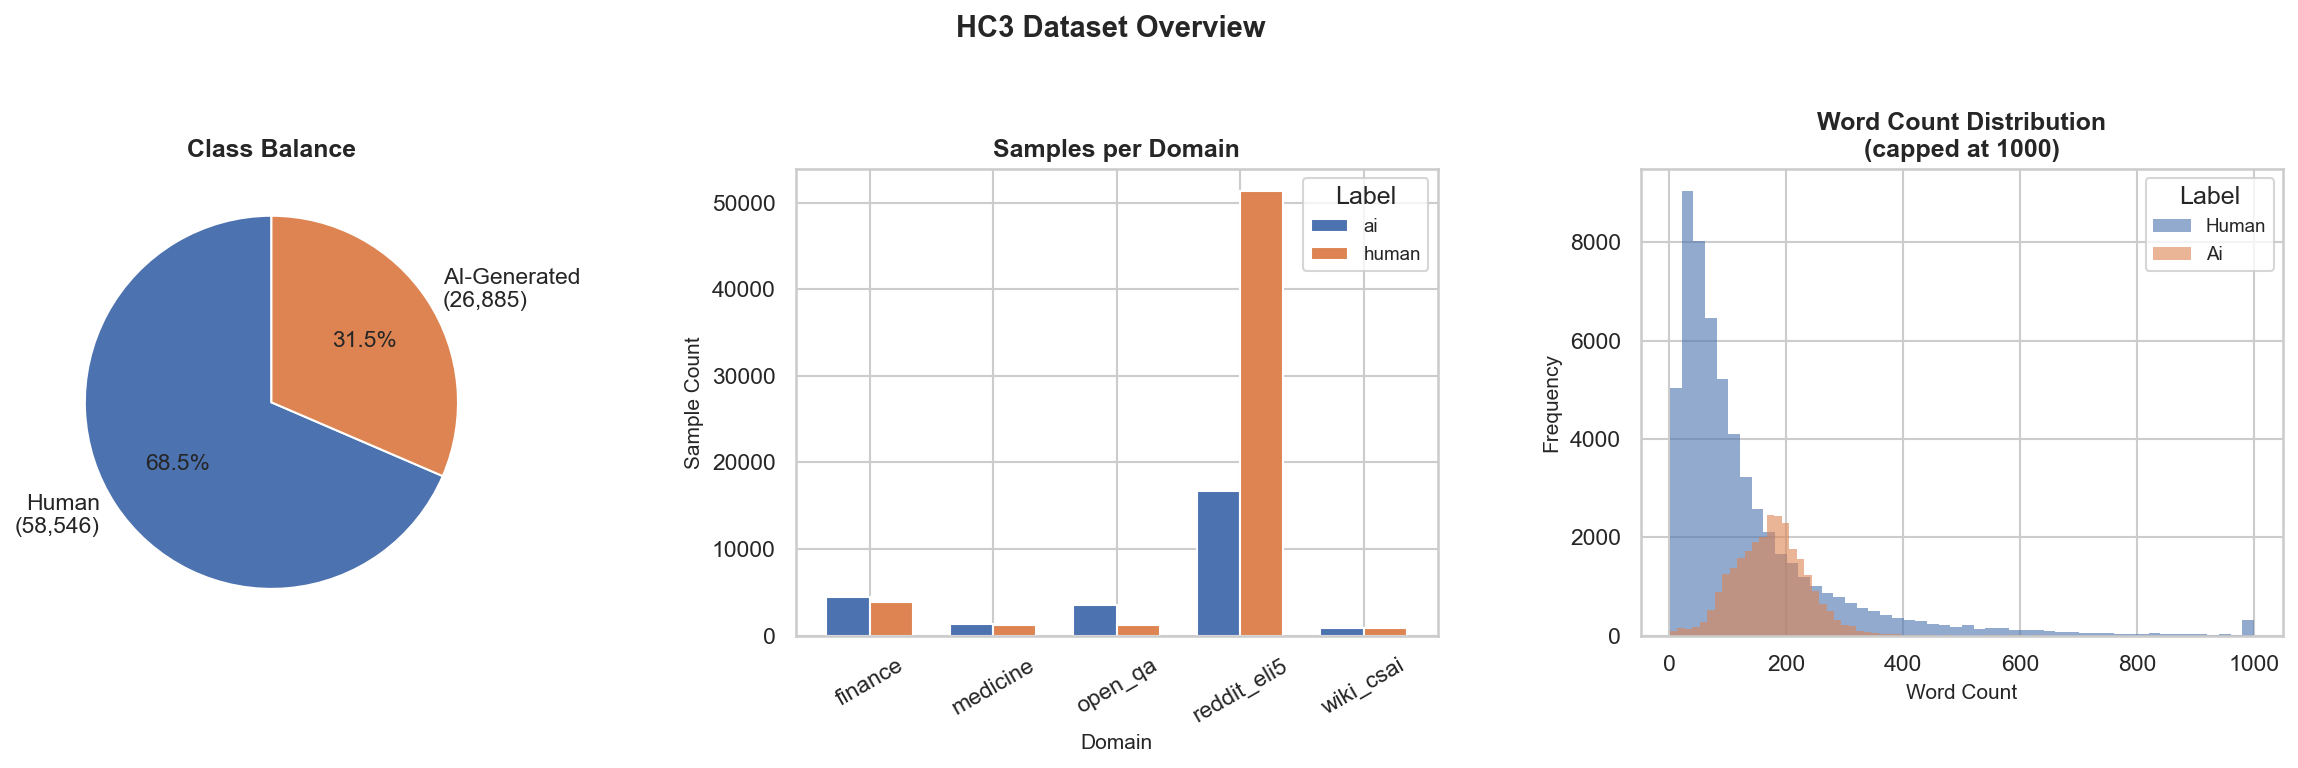

In [8]:
# ── Figure 1: Class distribution (Human vs AI) ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('HC3 Dataset Overview', fontsize=14, fontweight='bold', y=1.02)

# Plot 1 — Pie chart of class balance
counts = [n_human, n_ai]
labels = [f'Human\n({n_human:,})', f'AI-Generated\n({n_ai:,})']
colors = ['#4C72B0', '#DD8452']
axes[0].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Class Balance', fontsize=12, fontweight='bold')

# Plot 2 — Samples per domain (stacked bar)
domain_plot = df.groupby(['source', 'label_name']).size().unstack(fill_value=0)
domain_plot.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'],
                 edgecolor='white', width=0.7)
axes[1].set_title('Samples per Domain', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Domain', fontsize=10)
axes[1].set_ylabel('Sample Count', fontsize=10)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Label', fontsize=9)

# Plot 3 — Word count distribution by label
for label_name, colour in zip(['human', 'ai'], ['#4C72B0', '#DD8452']):
    subset = df[df['label_name'] == label_name]['word_count']
    # Cap at 1000 words for readability (long tails skew the plot)
    subset_capped = subset.clip(upper=1000)
    axes[2].hist(subset_capped, bins=50, alpha=0.6, color=colour,
                 label=label_name.capitalize(), edgecolor='none')
axes[2].set_title('Word Count Distribution\n(capped at 1000)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Word Count', fontsize=10)
axes[2].set_ylabel('Frequency', fontsize=10)
axes[2].legend(title='Label', fontsize=9)

plt.tight_layout()

# Save figure
fig_path = os.path.join(RESULTS_FIGS, 'fig01_hc3_dataset_overview.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
print(f'Figure saved to: {fig_path}')
plt.show()

Figure saved to: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig02_hc3_domain_breakdown.png


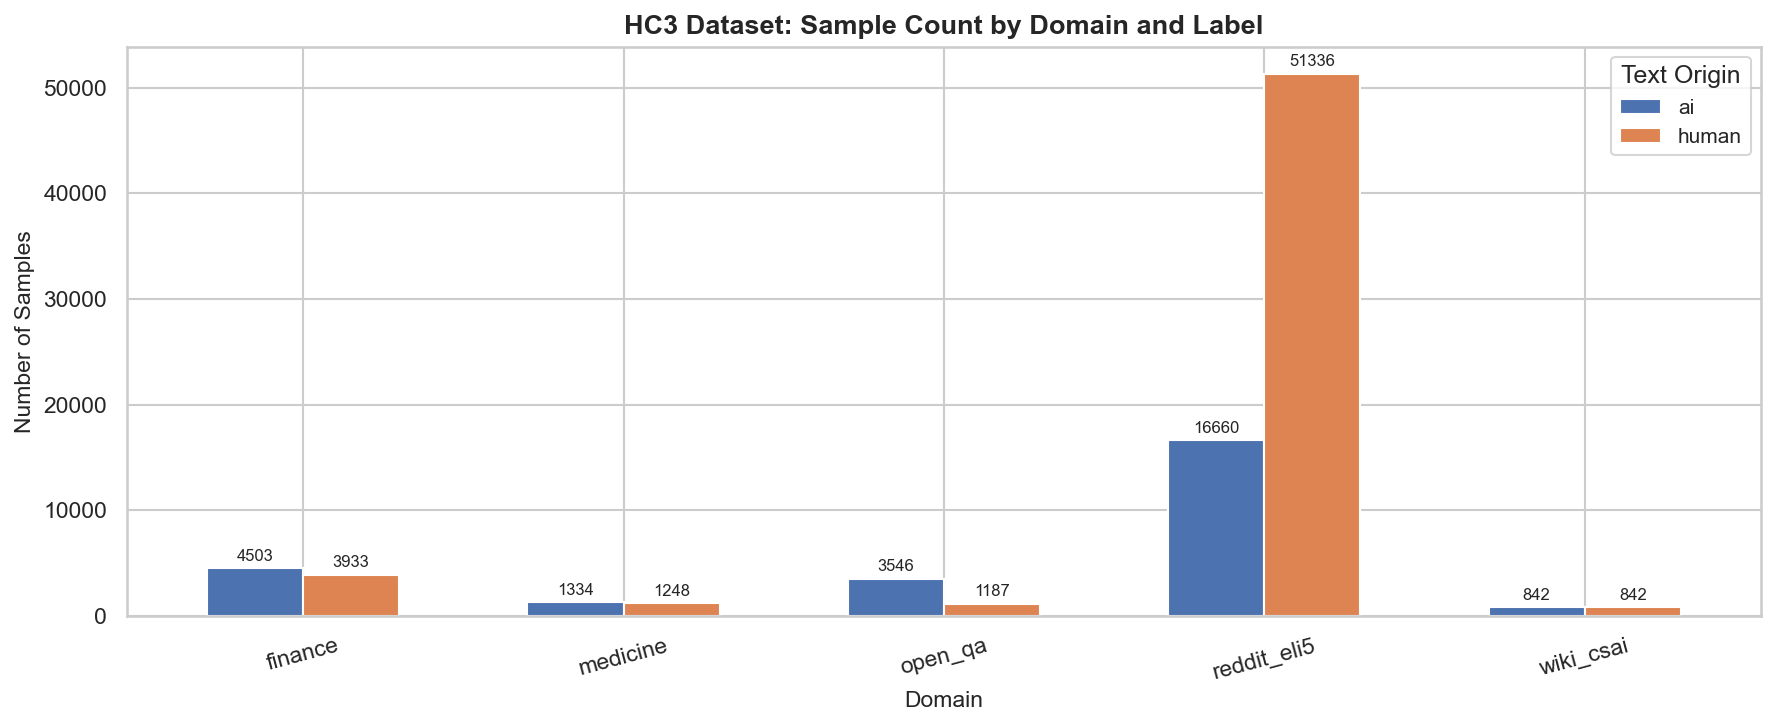

In [9]:
# ── Figure 2: Domain-wise class breakdown ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

domain_plot_full = df.groupby(['source', 'label_name']).size().unstack(fill_value=0)
domain_plot_full.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'],
                      edgecolor='white', width=0.6)

ax.set_title('HC3 Dataset: Sample Count by Domain and Label',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Domain', fontsize=11)
ax.set_ylabel('Number of Samples', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Text Origin', fontsize=10)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=8, padding=2)

plt.tight_layout()

fig_path2 = os.path.join(RESULTS_FIGS, 'fig02_hc3_domain_breakdown.png')
plt.savefig(fig_path2, bbox_inches='tight', dpi=150)
print(f'Figure saved to: {fig_path2}')
plt.show()

Figure saved to: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig03_hc3_word_count_boxplot.png


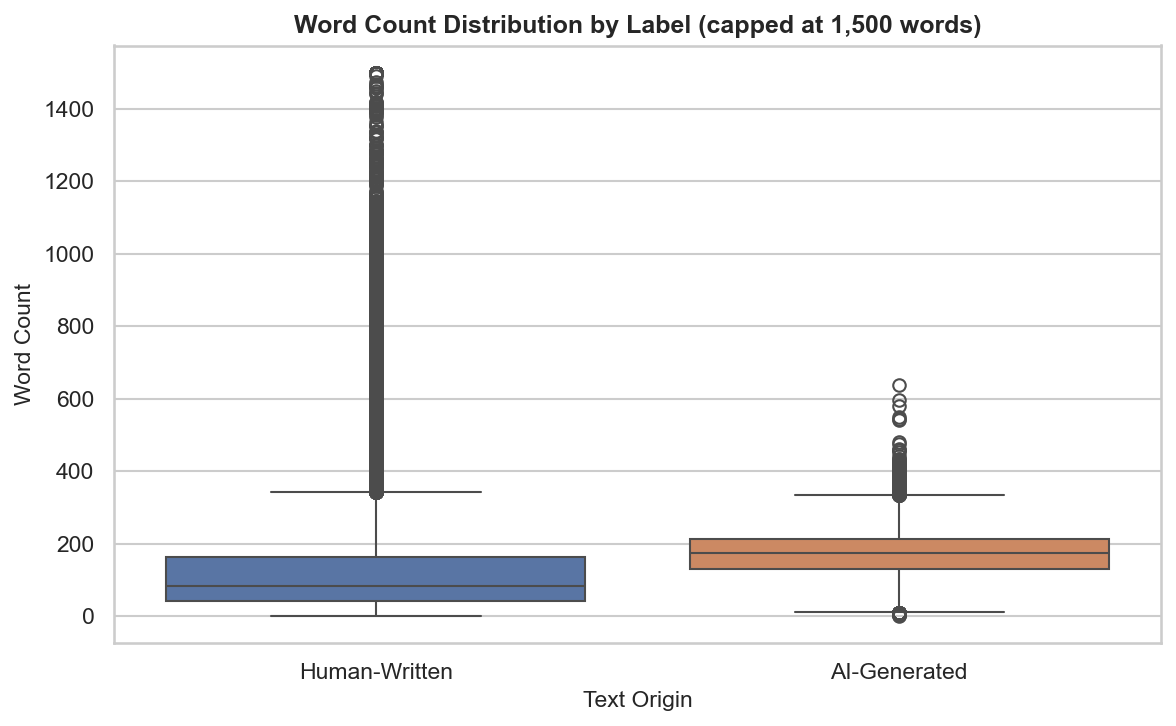

In [10]:
# ── Figure 3: Word count box plots ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# Clip extreme outliers so the box plot is readable
df_plot = df.copy()
df_plot['word_count_capped'] = df_plot['word_count'].clip(upper=1500)

sns.boxplot(data=df_plot, x='label_name', y='word_count_capped',
            palette={'human': '#4C72B0', 'ai': '#DD8452'}, ax=ax,
            order=['human', 'ai'])

ax.set_title('Word Count Distribution by Label (capped at 1,500 words)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Text Origin', fontsize=11)
ax.set_ylabel('Word Count', fontsize=11)
ax.set_xticklabels(['Human-Written', 'AI-Generated'])

plt.tight_layout()

fig_path3 = os.path.join(RESULTS_FIGS, 'fig03_hc3_word_count_boxplot.png')
plt.savefig(fig_path3, bbox_inches='tight', dpi=150)
print(f'Figure saved to: {fig_path3}')
plt.show()

## 8. Sample Texts: Side-by-Side Comparison

> **DISSERTATION NOTE:** This table goes into Chapter 4 (Implementation) as an example comparison.  
> It can also be used in Chapter 5 (Results) when comparing original vs rewritten samples.

In [11]:
# Show one human and one AI sample from the same domain side by side
sample_domain = 'medicine'   # change this to any domain of interest

human_sample = df[(df['source'] == sample_domain) & (df['label'] == 0)]['text'].iloc[0]
ai_sample    = df[(df['source'] == sample_domain) & (df['label'] == 1)]['text'].iloc[0]

print(f'=== Domain: {sample_domain.upper()} ===')
print('\n--- HUMAN-WRITTEN SAMPLE (first 500 chars) ---')
print(human_sample[:500])
print('\n--- AI-GENERATED SAMPLE (first 500 chars) ---')
print(ai_sample[:500])

=== Domain: MEDICINE ===

--- HUMAN-WRITTEN SAMPLE (first 500 chars) ---
Hi,     Thanks for the query. I understand your concern.         Primolute  N-a hormonal preparation of female sex hormone... is contraindicated in pregnancy.      It can cause fetal congenital abnormality &so such pregnancy (with intake of pills like promolute n ) needs to be terminated.   Thanks.

--- AI-GENERATED SAMPLE (first 500 chars) ---
It is not recommended to use Primolut N during pregnancy, as it can cause harm to the developing baby. Primolut N is a medication that contains the hormone norethisterone, which is used to regulate the menstrual cycle and treat menstrual disorders. When taken during pregnancy, it can interfere with the normal development of the fetus and increase the risk of birth defects. If you are pregnant and have taken Primolut N, it is important to speak with your healthcare provider as soon as possible. T


## 9. Save Dataset Summary to CSV

We save two files:
1. **Full flattened dataset** → `data/raw/hc3_full.csv` (all samples)
2. **Summary statistics table** → `results/tables/table01_hc3_dataset_stats.csv`

> **DISSERTATION NOTE:** `table01_hc3_dataset_stats.csv` becomes **Table 1** in Chapter 3 (Methodology).

In [12]:
# Save the full flattened DataFrame
full_csv_path = os.path.join(DATA_RAW, 'hc3_full.csv')
df.to_csv(full_csv_path, index=False, encoding='utf-8')
print(f'Full dataset saved: {full_csv_path}  ({len(df):,} rows)')

# Build a summary statistics table for the dissertation
summary_rows = []
for domain in sorted(df['source'].unique()):
    d = df[df['source'] == domain]
    summary_rows.append({
        'Domain':        domain,
        'Human Samples': int((d['label'] == 0).sum()),
        'AI Samples':    int((d['label'] == 1).sum()),
        'Total':         len(d),
        'Avg Words (Human)': round(d[d['label']==0]['word_count'].mean(), 1),
        'Avg Words (AI)':    round(d[d['label']==1]['word_count'].mean(), 1),
    })

# Add totals row
summary_rows.append({
    'Domain':        'TOTAL',
    'Human Samples': int(n_human),
    'AI Samples':    int(n_ai),
    'Total':         total,
    'Avg Words (Human)': round(df[df['label']==0]['word_count'].mean(), 1),
    'Avg Words (AI)':    round(df[df['label']==1]['word_count'].mean(), 1),
})

summary_df = pd.DataFrame(summary_rows)

# Save summary table
summary_path = os.path.join(RESULTS_TABLES, 'table01_hc3_dataset_stats.csv')
summary_df.to_csv(summary_path, index=False, encoding='utf-8')

print(f'Summary table saved: {summary_path}')
print('\n--- DATASET STATISTICS TABLE (for dissertation) ---')
print(summary_df.to_string(index=False))

Full dataset saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\data\raw\hc3_full.csv  (85,431 rows)
Summary table saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\tables\table01_hc3_dataset_stats.csv

--- DATASET STATISTICS TABLE (for dissertation) ---
     Domain  Human Samples  AI Samples  Total  Avg Words (Human)  Avg Words (AI)
    finance           3933        4503   8436              175.6           203.8
   medicine           1248        1334   2582               82.2           186.8
    open_qa           1187        3546   4733               31.4           118.4
reddit_eli5          51336       16660  67996              133.3           174.9
  wiki_csai            842         842   1684              195.5           185.3
      TOTAL          58546       26885  85431              133.9           173.2


## 10. Save Metadata JSON

Save key numbers as a JSON file so other notebooks can read them without recomputing.

In [13]:
# Build metadata dictionary
metadata = {
    'dataset': 'HC3 (Hello-SimpleAI/HC3)',
    'total_samples': total,
    'human_samples': int(n_human),
    'ai_samples':    int(n_ai),
    'num_domains':   n_domains,
    'domains':       domains,
    'avg_word_count_human': round(float(df[df['label']==0]['word_count'].mean()), 1),
    'avg_word_count_ai':    round(float(df[df['label']==1]['word_count'].mean()), 1),
    'label_map': {'0': 'human', '1': 'ai'},
    'notebook': '01_explore_hc3.ipynb',
    'files_saved': [
        full_csv_path,
        summary_path,
        fig_path,
        fig_path2,
        fig_path3
    ]
}

metadata_path = os.path.join(DATA_RAW, 'hc3_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print(f'Metadata saved: {metadata_path}')
print('\n--- Metadata ---')
print(json.dumps(metadata, indent=2))

Metadata saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\data\raw\hc3_metadata.json

--- Metadata ---
{
  "dataset": "HC3 (Hello-SimpleAI/HC3)",
  "total_samples": 85431,
  "human_samples": 58546,
  "ai_samples": 26885,
  "num_domains": 5,
  "domains": [
    "finance",
    "medicine",
    "open_qa",
    "reddit_eli5",
    "wiki_csai"
  ],
  "avg_word_count_human": 133.9,
  "avg_word_count_ai": 173.2,
  "label_map": {
    "0": "human",
    "1": "ai"
  },
  "notebook": "01_explore_hc3.ipynb",
  "files_saved": [
    "c:\\Users\\Abdul\\OneDrive\\Documents\\Uni\\MSc\\term3\\MSc-AI-Detection\\data\\raw\\hc3_full.csv",
    "c:\\Users\\Abdul\\OneDrive\\Documents\\Uni\\MSc\\term3\\MSc-AI-Detection\\results\\tables\\table01_hc3_dataset_stats.csv",
    "c:\\Users\\Abdul\\OneDrive\\Documents\\Uni\\MSc\\term3\\MSc-AI-Detection\\results\\figures\\fig01_hc3_dataset_overview.png",
    "c:\\Users\\Abdul\\OneDrive\\Documents\\Uni\\MSc\\term3\\MSc-AI-Detection\\results\\figures\\f

## 11. Notebook Summary

---

### What was done in this notebook
1. Loaded HC3 dataset from HuggingFace Hub
2. Flattened nested answer structure into a labelled flat DataFrame
3. Computed class balance, domain breakdown, and word count statistics
4. Produced 3 visualisation figures saved to `results/figures/`
5. Saved full dataset CSV to `data/raw/hc3_full.csv`
6. Saved dissertation statistics table to `results/tables/table01_hc3_dataset_stats.csv`
7. Saved metadata JSON to `data/raw/hc3_metadata.json`

### Files produced
| File | Location | Purpose |
|------|----------|---------|
| `hc3_full.csv` | `data/raw/` | Full flattened dataset |
| `hc3_metadata.json` | `data/raw/` | Key statistics for other notebooks |
| `table01_hc3_dataset_stats.csv` | `results/tables/` | Dissertation Table 1 |
| `fig01_hc3_dataset_overview.png` | `results/figures/` | Dissertation Figure 1 |
| `fig02_hc3_domain_breakdown.png` | `results/figures/` | Dissertation Figure 2 |
| `fig03_hc3_word_count_boxplot.png` | `results/figures/` | Dissertation Figure 3 |

### Next step
**Notebook 02:** `02_preprocess.ipynb` — Clean text, apply 70/15/15 split, save train/val/test CSVs.